# Electricity Demand Forecasting - Czech Republic

## Sample Notebook

All models (LSTM, Conv+GRU, WaveNet, TFT) were previously trained using the hyperparameters defined in their respective `train_*.py` scripts. 
These hyperparameters were selected as the ones that yielded the smallest MAE on the validation set. 
In this notebook, the trained models are only **loaded** — no training takes place here.

This notebook demonstrates the full pipeline:
1. Data download (weather + electricity load)
2. Data processing and feature engineering
3. Data preparation for training
4. Loading pre-trained models (LSTM, Conv+GRU, WaveNet, TFT)
5. Forecasting the last 14 days and comparing predictions against real data

**Important:** The last 14 data points are held out from training so that
we can compare all models' predictions against actual observed values.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Add project root to path so we can import config and scripts
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from config import (ROOT_DIR, DATA_CSV, RAW_DIR, PROCESSED_DIR, MODELS_DIR,
                     SEQ_LENGTH, AHEAD, BATCH_SIZE, SEED, CRISIS_START, CRISIS_END)

#print(f"Project root: {PROJECT_ROOT}")
print(f"Forecast horizon: {AHEAD} days")
print(f"Input window: {SEQ_LENGTH} days")

Forecast horizon: 14 days
Input window: 42 days


---
## 1. Data Download

### 1.1 Weather Data (Open-Meteo)
Weather data for 5 Czech macro-regions. No API key required.

In [2]:
# Weather data — run only if the file does not exist yet
from config import WEATHER_CSV

if WEATHER_CSV.exists():
    print("Weather data already exists")
    weather_df = pd.read_csv(WEATHER_CSV)
    print(f"Shape: {weather_df.shape}")
    print(f"Date range: {weather_df['date'].iloc[0]} to {weather_df['date'].iloc[-1]}")
else:
    print("Downloading weather data...")
    from scripts.download_weather import main as download_weather
    download_weather()
    weather_df = pd.read_csv(WEATHER_CSV)

weather_df.head()

Weather data already exists
Shape: (1378, 41)
Date range: 2022-07-01 to 2026-04-08


,date,CB_apparent_temperature_mean,CB_apparent_temperature_max,CB_apparent_temperature_min,CB_precipitation_sum,CB_rain_sum,CB_pressure_msl_mean,CB_cloud_cover_max,CB_dew_point_2m_mean,NB_apparent_temperature_mean,...,SM_cloud_cover_max,SM_dew_point_2m_mean,NM_apparent_temperature_mean,NM_apparent_temperature_max,NM_apparent_temperature_min,NM_precipitation_sum,NM_rain_sum,NM_pressure_msl_mean,NM_cloud_cover_max,NM_dew_point_2m_mean
0,2022-07-01,21.279676,27.198860,15.525938,11.999999,11.999999,1014.70844,100.0,17.239584,22.750711,...,100.0,17.929165,27.065804,33.556670,19.167160,13.2,13.2,1012.51666,100.0,17.710417
1,2022-07-02,17.763597,24.123472,11.581260,0.100000,0.100000,1023.89594,100.0,11.585418,18.728320,...,100.0,12.285419,17.055246,20.577526,14.812275,0.8,0.8,1023.17914,100.0,13.466667
2,2022-07-03,20.364752,27.688430,11.545122,0.000000,0.000000,1019.17914,100.0,13.306251,20.916094,...,76.0,13.360417,20.344542,27.040209,13.583359,0.2,0.2,1019.77080,100.0,14.358333
3,2022-07-04,21.989183,28.043358,16.418526,0.000000,0.000000,1017.09174,100.0,14.902084,23.008224,...,100.0,13.845834,23.421219,30.814987,15.075514,0.0,0.0,1016.75420,100.0,14.643750
4,2022-07-05,20.775162,25.069527,17.277628,0.000000,0.000000,1018.41254,100.0,13.652083,21.039637,...,100.0,16.054167,19.762907,21.468506,17.402197,17.7,17.7,1017.53754,100.0,16.529165


### 1.2 Electricity Load Data (ENTSO-E)

Requires an API key from ENTSO-E Transparency Platform.
See README.md for registration instructions.

In [3]:
# Electricity load data — run only if the file does not exist yet
from config import ENERGY_CSV

if ENERGY_CSV.exists():
    print(f"Energy data already exists")
    energy_df = pd.read_csv(ENERGY_CSV)
    print(f"Shape: {energy_df.shape}")
    print(f"Date range: {energy_df['date'].iloc[0]} to {energy_df['date'].iloc[-1]}")
else:
    print("Downloading energy data...")
    from scripts.download_energy import main as download_energy
    download_energy()
    energy_df = pd.read_csv(ENERGY_CSV)

energy_df.head()

Energy data already exists
Shape: (1376, 4)
Date range: 2022-07-01 to 2026-04-06


,date,load_min,load_mean,load_max
0,2022-07-01,5637.5,7090.7,8458.3
1,2022-07-02,4860.6,5731.0,6688.3
2,2022-07-03,4474.4,5576.9,6403.5
3,2022-07-04,4887.6,6141.8,7056.7
4,2022-07-05,4813.5,5709.2,6611.0


---
## 2. Data Processing

Load the processed dataset from `data/processed/data.csv`.
This file is created by the preprocessing pipeline which:
- Aggregates hourly ENTSO-E load to daily min, mean, max
- Merges with weather data from all 5 stations
- Adds the energy crisis flag and temporal features

In [4]:
df = pd.read_csv(DATA_CSV, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# One-hot encode day_type (must match training pipeline)
df = pd.get_dummies(df, columns=["day_type"], prefix="day", dtype=float)

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].iloc[0].date()} to {df['date'].iloc[-1].date()}")
print(f"\nColumns ({len(df.columns)}):")
print(list(df.columns))
df.head()

Shape: (1362, 55)
Date range: 2022-07-15 to 2026-04-06

Columns (55):
['date', 'load_min', 'load_mean', 'load_max', 'CB_apparent_temperature_mean', 'CB_apparent_temperature_max', 'CB_apparent_temperature_min', 'CB_precipitation_sum', 'CB_rain_sum', 'CB_pressure_msl_mean', 'CB_cloud_cover_max', 'CB_dew_point_2m_mean', 'NB_apparent_temperature_mean', 'NB_apparent_temperature_max', 'NB_apparent_temperature_min', 'NB_precipitation_sum', 'NB_rain_sum', 'NB_pressure_msl_mean', 'NB_cloud_cover_max', 'NB_dew_point_2m_mean', 'SB_apparent_temperature_mean', 'SB_apparent_temperature_max', 'SB_apparent_temperature_min', 'SB_precipitation_sum', 'SB_rain_sum', 'SB_pressure_msl_mean', 'SB_cloud_cover_max', 'SB_dew_point_2m_mean', 'SM_apparent_temperature_mean', 'SM_apparent_temperature_max', 'SM_apparent_temperature_min', 'SM_precipitation_sum', 'SM_rain_sum', 'SM_pressure_msl_mean', 'SM_cloud_cover_max', 'SM_dew_point_2m_mean', 'NM_apparent_temperature_mean', 'NM_apparent_temperature_max', 'NM_appar

,date,load_min,load_mean,load_max,CB_apparent_temperature_mean,CB_apparent_temperature_max,CB_apparent_temperature_min,CB_precipitation_sum,CB_rain_sum,CB_pressure_msl_mean,...,season_Spring,season_Summer,season_Fall,is_holiday,load_mean_lag7,load_mean_lag14,crisis,day_A,day_U,day_W
0,2022-07-15,5443.8,6687.5,7901.9,4.034409,4.781289,2.824088,0.0,0.0,267.669085,...,0.0,1.0,0.0,0,6367.7,7090.7,1,0.0,0.0,1.0
1,2022-07-16,4846.9,5691.8,6619.4,3.990228,4.745644,2.909633,0.0,0.0,267.902072,...,0.0,1.0,0.0,0,5593.3,5731.0,1,1.0,0.0,0.0
2,2022-07-17,4476.0,5579.0,6383.8,4.137014,5.930021,1.905504,0.0,0.0,269.359163,...,0.0,1.0,0.0,0,5513.0,5576.9,1,0.0,1.0,0.0
3,2022-07-18,5166.7,6799.6,8133.6,5.035710,7.233189,2.569488,0.0,0.0,269.014589,...,0.0,1.0,0.0,0,6717.9,6141.8,1,0.0,0.0,1.0
4,2022-07-19,5408.6,7081.5,8500.0,6.300414,8.642646,3.696652,0.0,0.0,268.076026,...,0.0,1.0,0.0,0,6806.3,5709.2,1,0.0,0.0,1.0


In [5]:
df.describe()

,date,load_min,load_mean,load_max,CB_apparent_temperature_mean,CB_apparent_temperature_max,CB_apparent_temperature_min,CB_precipitation_sum,CB_rain_sum,CB_pressure_msl_mean,...,season_Spring,season_Summer,season_Fall,is_holiday,load_mean_lag7,load_mean_lag14,crisis,day_A,day_U,day_W
count,1362,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,...,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000,1362.000000
mean,2024-05-25 12:00:00,5682.559398,7100.070558,8260.218282,2.174926,3.331064,1.080771,0.470303,0.434874,266.900201,...,0.218062,0.258443,0.261380,0.035242,7096.951322,7088.542584,0.190896,0.143172,0.143172,0.713656
min,2022-07-15 00:00:00,3797.700000,4960.600000,5923.300000,-3.209698,-2.698487,-4.432955,0.000000,0.000000,258.250730,...,0.000000,0.000000,0.000000,0.000000,4960.600000,4960.600000,0.000000,0.000000,0.000000,0.000000
25%,2023-06-20 06:00:00,5059.725000,6483.950000,7626.100000,0.112339,1.031219,-0.700525,0.000000,0.000000,265.551589,...,0.000000,0.000000,0.000000,0.000000,6483.950000,6471.275000,0.000000,0.000000,0.000000,0.000000
50%,2024-05-25 12:00:00,5529.650000,6983.700000,8211.950000,1.865310,3.073193,0.816294,0.052506,0.026253,266.965703,...,0.000000,0.000000,0.000000,0.000000,6980.050000,6968.000000,0.000000,0.000000,0.000000,1.000000
75%,2025-04-30 18:00:00,6289.300000,7797.275000,8901.575000,4.318059,5.555064,2.945971,0.498811,0.420052,268.340173,...,0.000000,1.000000,1.000000,0.000000,7790.575000,7780.475000,0.000000,0.000000,0.000000,1.000000
max,2026-04-06 00:00:00,8232.400000,10064.100000,11399.900000,7.716148,9.842209,6.203331,9.293640,9.293640,273.812365,...,1.000000,1.000000,1.000000,1.000000,10064.100000,10064.100000,1.000000,1.000000,1.000000,1.000000
std,NaN,861.182964,999.262982,1024.205527,2.505187,2.807271,2.248561,0.964499,0.946484,2.285847,...,0.413081,0.437940,0.439548,0.184459,999.242218,1001.211731,0.393151,0.350377,0.350377,0.452218


In [6]:
# Check for missing values
missing = df.isnull().sum()
if missing.any():
    print("Missing values:")
    print(missing[missing > 0])
else:
    print("No missing values.")

No missing values.


### Quick EDA: Electricity load over time

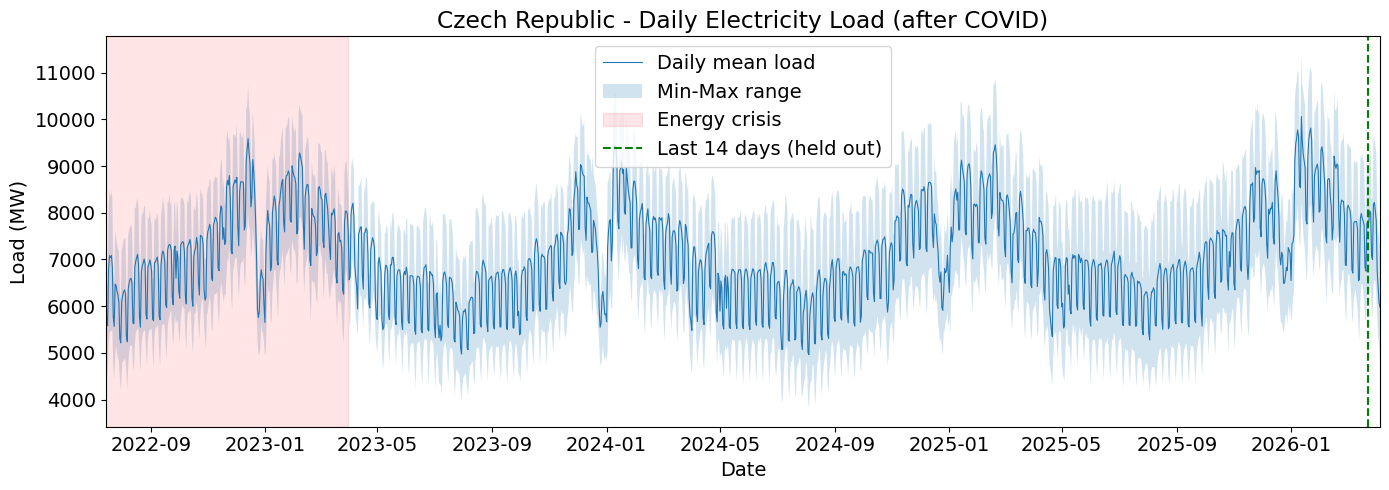

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
fontsize = 14
ax.plot(df["date"], df["load_mean"], label="Daily mean load", linewidth=0.8)
ax.fill_between(df["date"], df["load_min"], df["load_max"],
                alpha=0.2, label="Min-Max range")

# Mark energy crisis period
crisis_mask = (df["date"] >= CRISIS_START) & (df["date"] <= CRISIS_END)
if crisis_mask.any():
    ax.axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
               alpha=0.1, color="red", label="Energy crisis")

# Mark the last 14 days (held out for comparison)
ax.axvline(df["date"].iloc[-AHEAD], color="green", linestyle="--",
           label=f"Last {AHEAD} days (held out)")

ax.set_xlim(df["date"].iloc[0], df["date"].iloc[-1])
ax.set_xlabel("Date", fontsize=fontsize)
ax.set_ylabel("Load (MW)", fontsize=fontsize)
ax.set_title("Czech Republic - Daily Electricity Load (after COVID)", fontsize=fontsize * 1.2)
ax.legend(fontsize=fontsize)
ax.tick_params(axis="both", labelsize=fontsize)
plt.tight_layout()
plt.show()

---
## 3. Data Preparation for Training

Split data chronologically, normalise, and build `tf.data.Dataset` objects.

**Note:** The last 14 days are reserved as the final comparison window.
The training scripts use the last 2 months as validation and the last 1 month
as test, but here we explicitly hold out the last 14 days for visual comparison.

In [8]:
from scripts.data_to_training import load_training_data

data = load_training_data()

print(f"\nNumber of features: {data['n_features']}")
for name in ("train_ds", "valid_ds"):
    for X, Y in data[name].take(1):
        print(f"{name}: X shape={X.shape}, Y shape={Y.shape}")

I0000 00:00:1775752346.326721  409468 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3481 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050 Ti, pci bus id: 0000:01:00.0, compute capability: 6.1



Number of features: 54
train_ds: X shape=(32, 42, 54), Y shape=(32, 42, 14, 3)
valid_ds: X shape=(5, 42, 54), Y shape=(5, 42, 14, 3)


In [9]:
# Extract the actual values for the last 14 days (for comparison)
# These are the REAL values we will compare predictions against
last_14_df = df.iloc[-AHEAD:].copy()

actual_min  = last_14_df["load_min"].values
actual_mean = last_14_df["load_mean"].values
actual_max  = last_14_df["load_max"].values
actual_dates = last_14_df["date"].values

print(f"Held-out period: {last_14_df['date'].iloc[0].date()} to "
      f"{last_14_df['date'].iloc[-1].date()}")
print(f"Actual mean load range: {actual_mean.min():.0f} - {actual_mean.max():.0f} MW")

Held-out period: 2026-03-24 to 2026-04-06
Actual mean load range: 5977 - 8222 MW


In [10]:
# Prepare the input sequence for prediction:
# Take the SEQ_LENGTH days immediately before the last 14 days
n_targets = 3  # load_min, load_mean, load_max
feature_cols = data["feature_columns"]
scaler_mean = data["scaler_mean"]
scaler_std  = data["scaler_std"]

# The input window ends right before the held-out 14 days
input_window = df.iloc[-(AHEAD + SEQ_LENGTH):-AHEAD][feature_cols].values.astype(np.float32)
input_norm = (input_window - scaler_mean) / scaler_std
# Shape: (1, SEQ_LENGTH, n_features) for model input
X_input = input_norm[np.newaxis, ...]

print(f"Input window shape: {X_input.shape}")
print(f"Input period: {df['date'].iloc[-(AHEAD + SEQ_LENGTH)].date()} to "
      f"{df['date'].iloc[-(AHEAD + 1)].date()}")

Input window shape: (1, 42, 54)
Input period: 2026-02-10 to 2026-03-23


---
## 4. Load Pre-trained Models and Generate Predictions

We load each saved model and predict the next 14 days.
Models were trained separately using the `train_*.py` scripts.

In [11]:
def inverse_transform_targets(y_pred_norm):
    """Convert normalised predictions back to MW."""
    target_mean = scaler_mean[:n_targets]
    target_std  = scaler_std[:n_targets]
    return y_pred_norm * target_std + target_mean

# Dictionary to store all models' predictions
predictions = {}

### 4.1 LSTM Seq2Seq

In [12]:
lstm_path = MODELS_DIR / "lstm_seq2seq.keras"
if lstm_path.exists():
    lstm_model = tf.keras.models.load_model(lstm_path)
    print("Loaded LSTM model")
    lstm_model.summary()

    Y_pred = lstm_model.predict(X_input)
    # Y_pred shape: (1, seq_length, AHEAD, n_targets) — take last time step
    y_pred_norm = Y_pred[0, -1]  # (AHEAD, n_targets)
    predictions["LSTM"] = inverse_transform_targets(y_pred_norm)
    print(f"LSTM predictions shape: {predictions['LSTM'].shape}")
else:
    print(f"LSTM model not found at {lstm_path}")
    print("Run 'python scripts/train_lstm.py' first.")

Loaded LSTM model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, None, 32)       │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 32)       │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 256)      │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 128)      │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 42)       │         5,418 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, None, 14, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,022 (2.99 MB)

 Trainable params: 392,010 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 392,012 (1.50 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
LSTM predictions shape: (14, 3)


### 4.2 Conv1D + GRU Hybrid

In [13]:
conv_gru_path = MODELS_DIR / "conv_gru_hybrid.keras"
if conv_gru_path.exists():
    conv_gru_model = tf.keras.models.load_model(conv_gru_path)
    print("Loaded Conv+GRU model")
    conv_gru_model.summary()

    Y_pred = conv_gru_model.predict(X_input)
    # Y_pred shape: (1, seq_length, AHEAD, n_targets) — take last time step
    y_pred_norm = Y_pred[0, -1]  # (AHEAD, n_targets)
    predictions["Conv+GRU"] = inverse_transform_targets(y_pred_norm)
    print(f"Conv+GRU predictions shape: {predictions['Conv+GRU'].shape}")
else:
    print(f"Conv+GRU model not found at {conv_gru_path}")
    print("Run 'python scripts/train_conv_gru.py' first.")

Loaded Conv+GRU model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, None, 32)       │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, None, 32)       │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, None, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, None, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, None, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 256)      │       148,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 128)      │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 42)       │         5,418 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, None, 14, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,334 (2.31 MB)

 Trainable params: 302,666 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302,668 (1.15 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Conv+GRU predictions shape: (14, 3)


### 4.3 WaveNet

In [14]:
# WaveNet uses a custom layer — need to register it for loading
from scripts.train_wavenet import GatedActivationUnit

wavenet_path = MODELS_DIR / "wavenet.keras"
if wavenet_path.exists():
    wavenet_model = tf.keras.models.load_model(
        wavenet_path,
        custom_objects={"GatedActivationUnit": GatedActivationUnit}
    )
    print("Loaded WaveNet model")
    wavenet_model.summary()

    Y_pred = wavenet_model.predict(X_input)
    # Y_pred shape: (1, seq_length, AHEAD, n_targets) — take last time step
    y_pred_norm = Y_pred[0, -1]  # (AHEAD, n_targets)
    predictions["WaveNet"] = inverse_transform_targets(y_pred_norm)
    print(f"WaveNet predictions shape: {predictions['WaveNet'].shape}")
else:
    print(f"WaveNet model not found at {wavenet_path}")
    print("Run 'python scripts/train_wavenet.py' first.")

Loaded WaveNet model


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 54)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, None, 64)  │      6,976 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, None, 128) │     16,512 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 64)  │          0 │ conv1d_1[0][0]    │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, None, 64)  │      4,160 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, None, 128) │     16,512 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 64)  │          0 │ conv1d_3[0][0]    │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, None, 64)  │      4,160 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, None, 128) │     16,512 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 64)  │          0 │ conv1d_5[0][0]    │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, None, 64)  │      4,160 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 64)  │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, None, 128) │     16,512 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 64)  │          0 │ conv1d_7[0][0]    │
│ (GatedActivationUn… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, None, 64)  │      4,160 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 64)  │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, None, 128) │     16,512 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_u… │ (None, None, 64)  │          0 │ conv1d_9[0][0]    │
│ (GatedActivationUn… │                   │            │                 

 Total params: 358,486 (1.37 MB)

 Trainable params: 179,242 (700.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 179,244 (700.18 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
WaveNet predictions shape: (14, 3)


I0000 00:00:1775752352.540873  409621 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


### 4.4 Temporal Fusion Transformer (TFT)

TFT is a PyTorch model — loaded separately via pytorch-lightning checkpoint.
It predicts `load_min`, `load_mean`, `load_max` (3 targets).

In [15]:
tft_path = MODELS_DIR / "tft_model.ckpt"
if tft_path.exists():
    import torch
    import lightning.pytorch as pl
    from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet, GroupNormalizer, MultiNormalizer
    from pytorch_forecasting.metrics import MAE, MultiLoss

    # Rebuild the dataset definition (needed for TFT prediction)
    tft_df = df.copy()
    tft_df["time_idx"] = np.arange(len(tft_df))
    tft_df["group"] = "CZ"

    targets = ["load_min", "load_mean", "load_max"]
    REGION_PREFIXES = ("CB_", "NB_", "SB_", "SM_", "NM_")
    time_varying_known = [c for c in tft_df.columns
                          if c.startswith((*REGION_PREFIXES,
                                           "day_W", "day_A", "day_U",
                                           "season_", "is_holiday"))]
    time_varying_unknown = [c for c in tft_df.columns
                            if c not in ["date", "time_idx", "group"] + targets
                            and c not in time_varying_known]

    # Use all data except last AHEAD days for the dataset definition
    training_cutoff = len(tft_df) - AHEAD - 1

    tft_dataset = TimeSeriesDataSet(
        tft_df[tft_df.time_idx <= training_cutoff],
        time_idx="time_idx",
        target=targets,
        group_ids=["group"],
        max_encoder_length=SEQ_LENGTH,
        max_prediction_length=AHEAD,
        time_varying_known_reals=time_varying_known if time_varying_known else None,
        time_varying_unknown_reals=time_varying_unknown,
        target_normalizer=MultiNormalizer([GroupNormalizer(groups=["group"]) for _ in targets]),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    # Create a prediction dataset for the last 14 days
    predict_dataset = TimeSeriesDataSet.from_dataset(
        tft_dataset, tft_df, stop_randomization=True
    )
    predict_dl = predict_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

    # Load model
    tft_model = TemporalFusionTransformer.load_from_checkpoint(str(tft_path))
    print("Loaded TFT model")

    # Predict
    tft_predictions = tft_model.predict(predict_dl, trainer_kwargs=dict(accelerator="cpu"))
    # tft_predictions is a list of tensors (one per target)
    # Stack as (AHEAD, 3) with columns [load_min, load_mean, load_max]
    predictions["TFT"] = np.column_stack([p[-1].numpy() for p in tft_predictions])
    print(f"TFT predictions shape: {predictions['TFT'].shape}")
else:
    print(f"TFT model not found at {tft_path}")
    print("Run 'python scripts/train_tft.py' first.")

/home/felipe/my_python_env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/felipe/my_python_env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/felipe/my_python_env/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and ar

Loaded TFT model


/home/felipe/my_python_env/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/felipe/my_python_env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


TFT predictions shape: (14, 3)


---
## 5. Results: Predictions vs Real Data

Compare all models' predictions against the actual electricity load
for the last 14 days.

### 5.1 Numerical Comparison

In [16]:
# Build a comparison DataFrame for load_mean
comparison = pd.DataFrame({
    "date": actual_dates,
    "actual_mean": actual_mean,
})

for model_name, preds in predictions.items():
    # All models predict (AHEAD, 3) — column 1 is load_mean
    comparison[f"{model_name}_mean"] = preds[:, 1]

comparison

,date,actual_mean,LSTM_mean,Conv+GRU_mean,WaveNet_mean,TFT_mean
0,2026-03-24,7797.2,7855.362305,7859.870117,7513.236816,7703.276855
1,2026-03-25,7793.4,7896.333008,7757.252441,7601.549805,7684.703125
2,2026-03-26,8045.9,7813.193359,7676.247070,7655.811523,8002.066406
3,2026-03-27,7991.9,7670.795410,7480.562012,7611.787598,8105.243164
4,2026-03-28,7075.6,6887.869141,6805.579590,6878.822266,6967.647461
5,2026-03-29,7001.7,6660.474121,6755.817383,6330.878906,6841.028320
6,2026-03-30,8180.9,7474.612305,7621.957031,7197.932129,8103.576172
7,2026-03-31,8221.8,7720.699219,7784.102539,7879.958008,8216.302734
8,2026-04-01,8041.5,7822.013672,7739.601074,7754.876953,8086.967773
9,2026-04-02,7829.2,7730.028809,7676.933105,7559.689453,7969.173340


In [17]:
# Compute error metrics for each model (on load_mean)
from sklearn.metrics import mean_absolute_error, mean_squared_error

metrics = []
for model_name in predictions:
    col = f"{model_name}_mean"
    if col in comparison.columns:
        mae = mean_absolute_error(comparison["actual_mean"], comparison[col])
        rmse = np.sqrt(mean_squared_error(comparison["actual_mean"], comparison[col]))
        mape = np.mean(np.abs(
            (comparison["actual_mean"] - comparison[col]) / comparison["actual_mean"]
        )) * 100
        metrics.append({"Model": model_name, "MAE (MW)": mae,
                        "RMSE (MW)": rmse, "MAPE (%)": mape})

metrics_df = pd.DataFrame(metrics).sort_values("MAE (MW)")
metrics_df

,Model,MAE (MW),RMSE (MW),MAPE (%)
3,TFT,135.093304,200.604962,1.921682
0,LSTM,406.954388,524.910328,5.867359
1,Conv+GRU,439.112360,564.672926,6.360588
2,WaveNet,497.672949,581.358179,7.065770


### 5.2 Visual Comparison: Mean Load

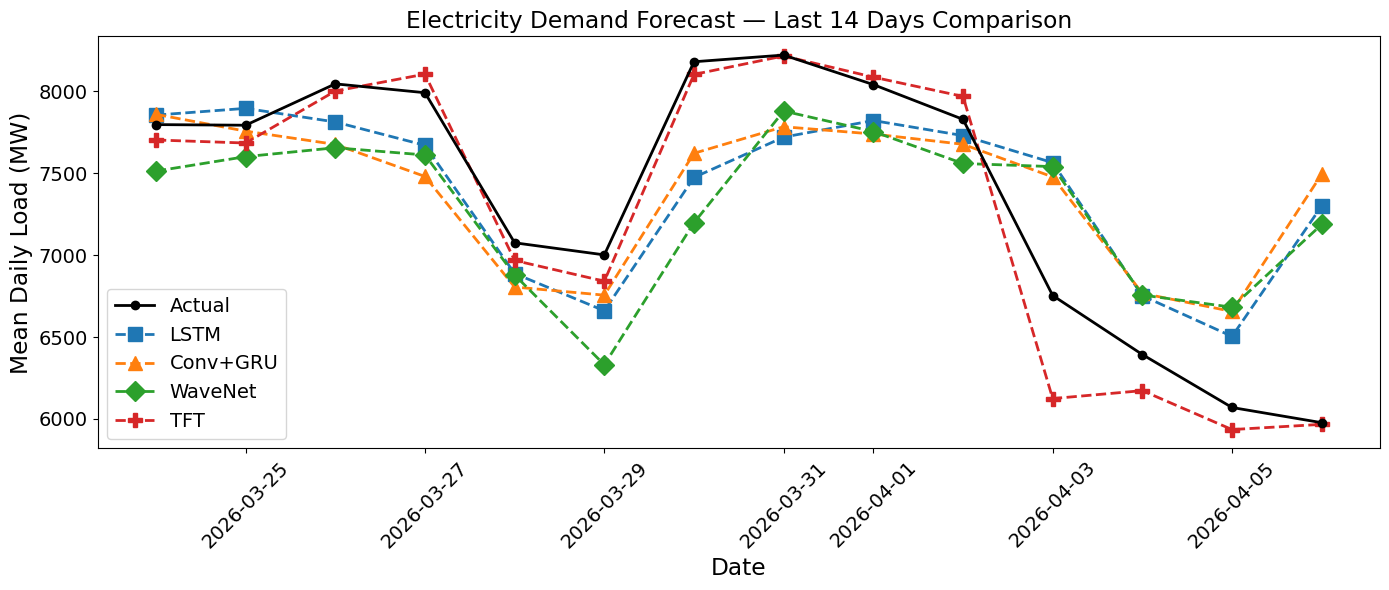

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
fontsize=14
# Plot actual data
ax.plot(actual_dates, actual_mean, "ko-", linewidth=2, markersize=6,
        label="Actual", zorder=5)

# Plot each model's predictions
colors = {"LSTM": "#1f77b4", "Conv+GRU": "#ff7f0e",
          "WaveNet": "#2ca02c", "TFT": "#d62728"}
markers = {"LSTM": "s", "Conv+GRU": "^", "WaveNet": "D", "TFT": "P"}

for model_name in predictions:
    col = f"{model_name}_mean"
    if col in comparison.columns:
        ax.plot(actual_dates, comparison[col].values, 
                marker=markers.get(model_name, "o"),
                color=colors.get(model_name, "gray"),
                linestyle="--", linewidth=2, markersize=10,
                label=model_name)

ax.set_xlabel("Date", fontsize=fontsize*1.2)
ax.set_ylabel("Mean Daily Load (MW)", fontsize=fontsize*1.2)
ax.set_title(f"Electricity Demand Forecast — Last {AHEAD} Days Comparison", 
             fontsize=fontsize*1.2)
ax.legend(fontsize=fontsize)
plt.xticks(rotation=45, fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.show()

### 5.3 Visual Comparison: Min/Max Range

All models (including TFT) predict load_min, load_mean, and load_max.

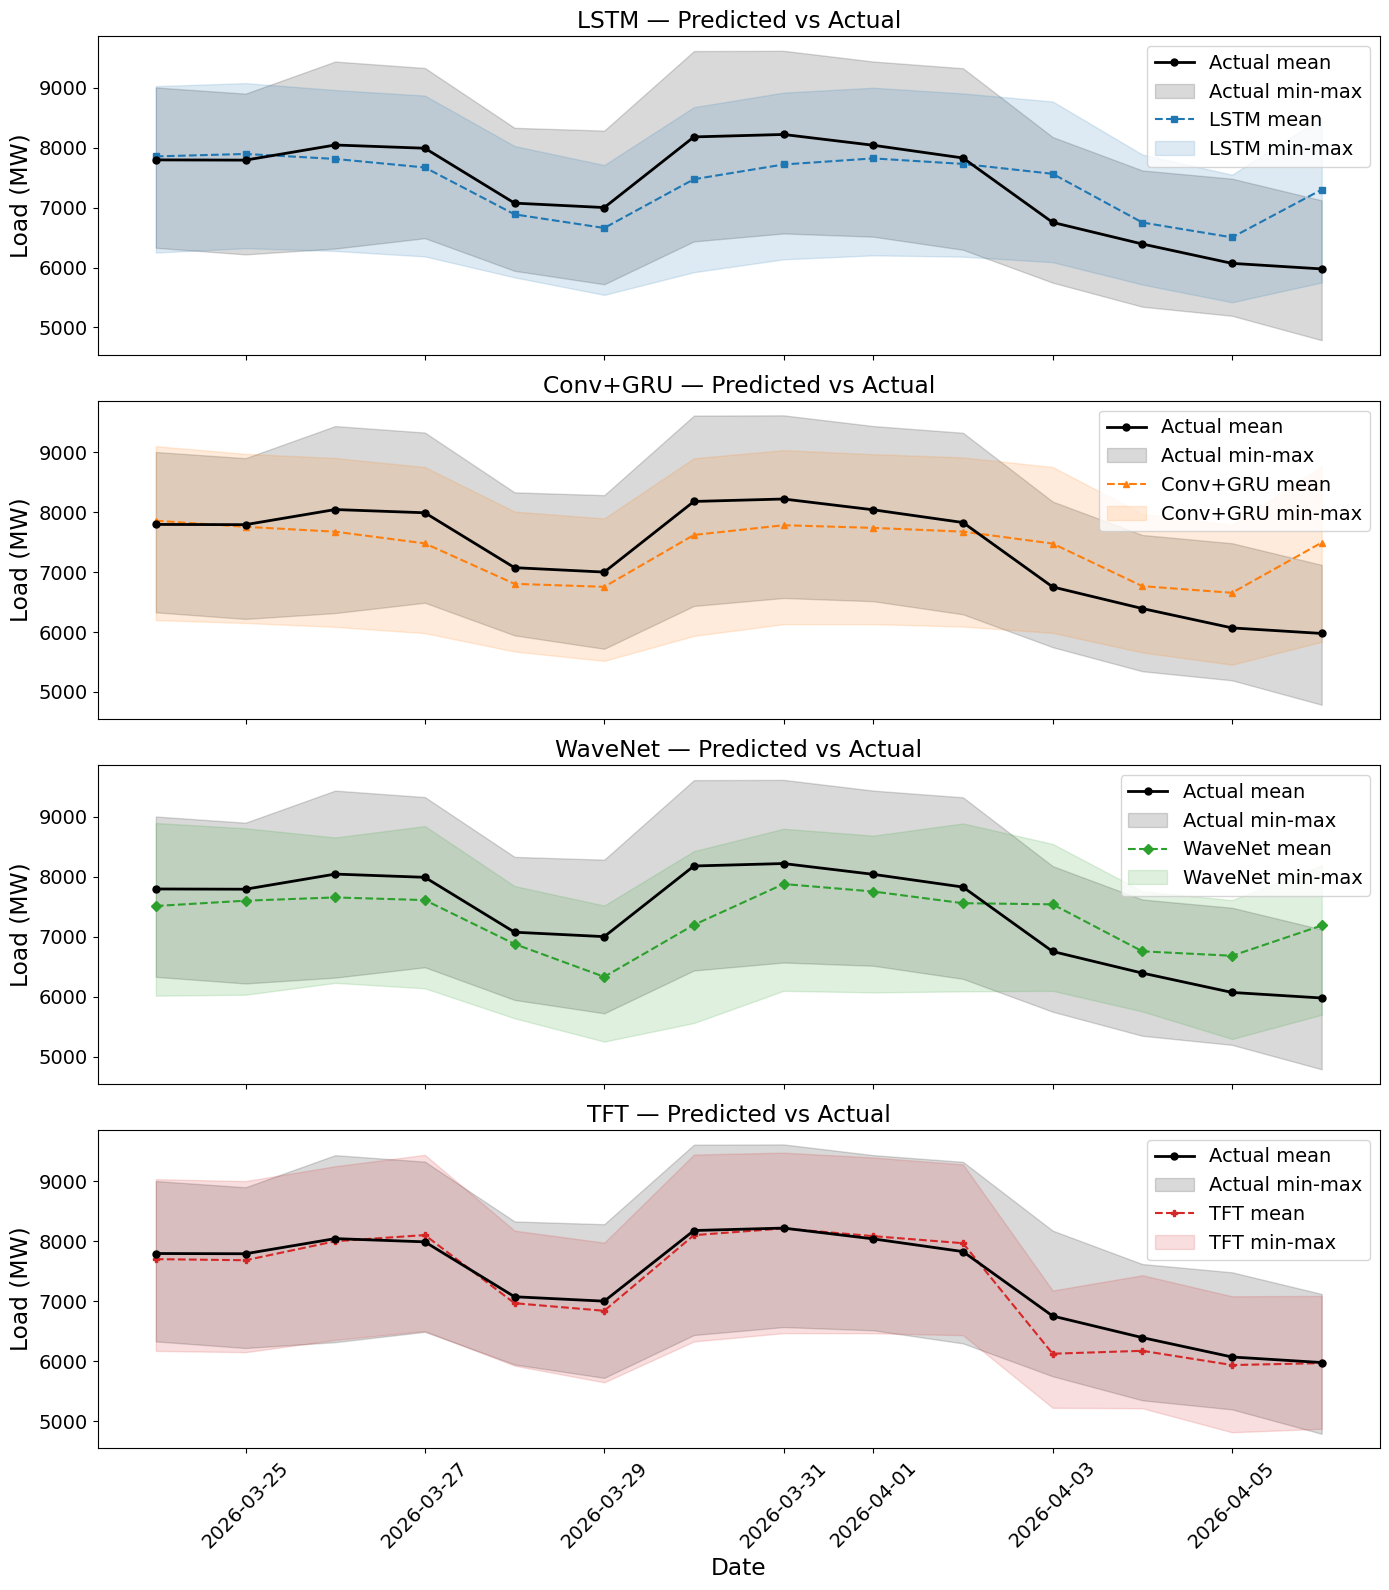

In [19]:
all_models = {k: v for k, v in predictions.items() if v.ndim == 2 and v.shape[1] == 3}
fontsize = 14

if all_models:
    n_models = len(all_models)
    fig, axes = plt.subplots(n_models, 1, figsize=(14, 4 * n_models), sharex=True)
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, preds) in zip(axes, all_models.items()):
        # Actual
        ax.plot(actual_dates, actual_mean, "ko-", linewidth=2,
                markersize=5, label="Actual mean", zorder=5)
        ax.fill_between(actual_dates, actual_min, actual_max,
                        alpha=0.15, color="black", label="Actual min-max")

        # Predicted
        pred_min, pred_mean, pred_max = preds[:, 0], preds[:, 1], preds[:, 2]
        color = colors.get(model_name, "blue")
        ax.plot(actual_dates, pred_mean, "--", color=color, linewidth=1.5,
                marker=markers.get(model_name, "o"), markersize=5,
                label=f"{model_name} mean")
        ax.fill_between(actual_dates, pred_min, pred_max,
                        alpha=0.15, color=color, label=f"{model_name} min-max")

        ax.set_ylabel("Load (MW)", fontsize=fontsize*1.2)
        ax.set_title(f"{model_name} — Predicted vs Actual", fontsize=fontsize * 1.2)
        ax.legend(loc="upper right", fontsize=fontsize)
        ax.tick_params(axis="both", labelsize=fontsize)

    axes[-1].set_xlabel("Date", fontsize=fontsize*1.2)
    plt.xticks(rotation=45, fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.show()
else:
    print("No models loaded — train models first.")

### 5.4 Prediction Error per Day

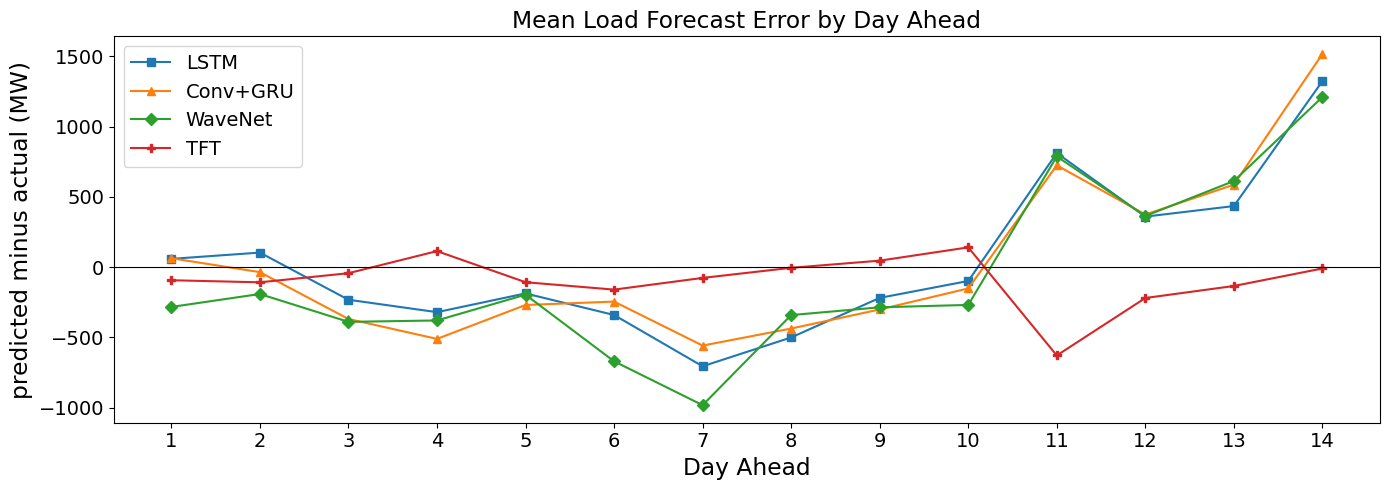

In [20]:
if predictions:
    fig, ax = plt.subplots(figsize=(14, 5))
    fontsize = 14

    days = np.arange(1, AHEAD + 1)
    for model_name in predictions:
        col = f"{model_name}_mean"
        if col in comparison.columns:
            errors = (comparison[col].values - comparison["actual_mean"].values)
            ax.plot(days, errors, marker=markers.get(model_name, "o"),
                    color=colors.get(model_name, "gray"),
                    linestyle="-", linewidth=1.5, label=model_name)

    ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
    ax.set_xlabel("Day Ahead", fontsize=fontsize*1.2)
    ax.set_ylabel("predicted minus actual (MW)", fontsize=fontsize*1.2)
    ax.set_title("Mean Load Forecast Error by Day Ahead", fontsize=fontsize * 1.2)
    ax.set_xticks(days)
    ax.tick_params(axis="both", labelsize=fontsize)
    ax.legend(fontsize=fontsize)
    plt.tight_layout()
    plt.show()
else:
    print("No predictions available — load models first.")

---
## 6. Summary

In [21]:
if 'metrics_df' in dir() and len(metrics_df) > 0:
    print("=" * 55)
    print(f"  Model Comparison — {AHEAD}-day Forecast")
    print("=" * 55)
    print(metrics_df.to_string(index=False))
    print("=" * 55)
    best = metrics_df.iloc[0]
    print(f"\n  Best model: {best['Model']} "
          f"(MAE={best['MAE (MW)']:.1f} MW, MAPE={best['MAPE (%)']:.2f}%)")
else:
    print("No metrics computed — train and load models first.")

  Model Comparison — 14-day Forecast
   Model   MAE (MW)  RMSE (MW)  MAPE (%)
     TFT 135.093304 200.604962  1.921682
    LSTM 406.954388 524.910328  5.867359
Conv+GRU 439.112360 564.672926  6.360588
 WaveNet 497.672949 581.358179  7.065770

  Best model: TFT (MAE=135.1 MW, MAPE=1.92%)


## Conclusion

The **Temporal Fusion Transformer (TFT)** consistently outperforms all other models in this backtest, achieving the lowest MAE and MAPE. The **LSTM** and **Conv+GRU** models, both using Bidirectional RNN layers with a dilated causal Conv1D front-end, perform competitively with each other. The **WaveNet** model, a purely convolutional architecture, shows the weakest performance — likely due to the limited dataset size (~1,370 daily observations), as WaveNet was originally designed for tasks with much larger volumes of data.

A key reason for TFT's advantage is visible in the plots above: the test period includes **Easter 2026** (April 3 and 6 are public holidays in the Czech Republic). On these days, electricity consumption drops significantly despite falling on weekdays.

The TFT handles this well thanks to its **variable selection network**, which can learn to give the `is_holiday` feature high importance at specific timesteps, effectively overriding the dominant weekday consumption pattern. The RNN-based models, on the other hand, compress all 54 input features into a hidden state and struggle to give sufficient weight to the holiday flag when the weekday pattern is so strong. As a result, they predict high weekday-like consumption on holidays, while TFT correctly predicts a drop.

This makes TFT the best-performing model for real-world forecasting, especially in periods where holidays disrupt regular weekly patterns.
